# MTH/CMSE 314
# IC16: Diagonalization & Markov Models
### <p style="text-align: right;"> &#9989; **Mikel Good** </p>

#### Goals
- Diagonalizing a $2\times 2$ and a $3\times 3$ matrix by hand, by computing the eigenvalues, and then bases of eigenspaces of each eigenvalue.
- Diagonalizing a matrix using python.
- Applying diagonalization to compute matrix powers.
- Modeling problems as Markov models/processes and finding the steady state of these models.

#### Please read the following before you begin: 

- <font color=#641e16> We recommended that you complete the After-Class Assignments (ACs) before starting the In-Class Assignments (ICs),
    
- <font color=#641e16> Keep your lecture notes handy for easy reference.

- <font color=#641e16> Use class time to collaborate with your group and get help from instructors, as IC solutions will not be provided.

---
## 1. Diagonalization
### Review:
1.  An $n\times n$ (square) matrix is _diagonalizable_ if it is similar to a diagonal matrix. That is, if there exists an invertible matrix $P$ and a diagonal matrix $D$ such that 
$$A = PDP^{-1}.$$
2. An $n\times n$ (square) matrix is _diagonalizable_ if and only if it has $n$ **linearly independent** eigenvectors.
3. An $n\times n$ (square) matrix is _diagonalizable_ if and only if the sum of the dimensions of its eigenspaces is $n$. In particular, a matrix $A$ with $n$ distinct eigenvalues is diagonalizable. 
4. If an $n\times n$ (square) matrix is diagonalizable, to diagonalize it:
   - construct $P$ by taking the $n$ linearly independent eigenvectors of $A$ as respective columns of $P$.
   - construct $D$ by taking the main diagonal entries to be the respective eigenvalues of $a$ corresponding to the eigenvectors in $P$.

In other words, if matrix $A$ has linearly independent eigenvectors ($v_1, \ldots v_n$) then $A$ is diagonalizable with the following solution:
    $$A = PDP^{-1},$$
    where $P = \left[ v_1^T, \ldots, v_n^T \right].$
    In other words, each column of $P$ is a linearly independent eigenvector of $A$;\
    and the diagonal matrix $D$ is
    $ D = 
    \left[
    \begin{matrix}
        \lambda_1  & 0  & 0 \\
        0   & \ddots & 0  \\
        0   & 0 & \lambda_n 
    \end{matrix}
    \right],$ where each $\lambda_i$ are the respective eigenvalues of $A$.

-----

&#9989; <font color=blue>**<font color=red>Do this:</font>** Run the cell below to make the necessary package imports before you proceed.

In [2]:
%matplotlib inline
import matplotlib.pylab as plt
import numpy as np
import sympy as sym
sym.init_printing(use_unicode=True)

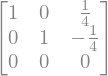

In [3]:
j = np.array([
    [-2, 2, -1],
    [1, -3, 1],
    [4, -4, 2]
])

sym.Matrix(j).rref()[0]

---
### 1.1 Diagonalization by hand
&#9989; <font color=blue>**Problem (BY HAND)** <font color=blue>Consider $ A = \begin{bmatrix}-4& -6\\3& 5\end{bmatrix}.$
Find a matrix $P$ such that $PAP^{-1}$ is diagonal.
    
Import a photo of your calculations or type in latex

`` Import a photo of your calculations or type in latex``

&#9989; <font color=blue>**Problem (BY HAND)** <font color=blue>The matrix $ A = \begin{bmatrix} 1& 2& -1\\1& 0 & 1\\4&-4&5\end{bmatrix}$ has characteristic equation $-(\lambda-3)(\lambda-2)(\lambda-1)$. Find the eigenvalues of $A$. Is $A$ diagonalizable? Justify your answer. If it is, diagonalize it.

`` Import a photo of your calculations or type in LaTeX.``

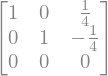

In [4]:
j = np.array([
    [-2, 2, -1],
    [1, -3, 1],
    [4, -4, 2]
])

sym.Matrix(j).rref()[0]

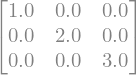

In [8]:
P = np.array([
    [-1, 2, -1],
    [1, -1, 1],
    [2, -4, 4]
])

P_inv = np.linalg.inv(P)

A = np.array([
    [1, 2, -1],
    [1, 0, 1],
    [4, -4, 5]
])

D = (P_inv @ A) @ P

sym.Matrix(D)

---
### 1.2 Diagonalization using `Numpy`
&#9989; <font color=blue>**<font color=red>Do this:</font>** Using ```numpy```, Diagonalize (i.e. find the matrices  $P$ and $D$) the following matrix 
$$A=\begin{bmatrix}
5 & -2 & 2\\
4 & -3 & 4\\
4 &-6 &7
\end{bmatrix}.$$

<font color=blue> _(Hint: consider using `np.diag`)_

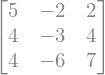

In [9]:
A = np.matrix([[5, -2, 2], [4, -3, 4], [4,-6,7]])
sym.Matrix(A)

In [50]:
eigvec3

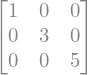

In [81]:
# Put your answer here
eigvecs = sym.Matrix(A).eigenvects()
eigvec1 = eigvecs[0][2][0]
eigvec2 = eigvecs[1][2][0]
eigvec3 = eigvecs[2][2][0]

eigval1 = eigvecs[0][0]
eigval2 = eigvecs[1][0]
eigval3 = eigvecs[2][0]

D = np.diag((eigval1, eigval2, eigval3))
sym.Matrix(D)

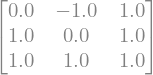

In [82]:
vals = list(eigvec1) + list(eigvec2) + list(eigvec3)
P = np.zeros((3,3))

count = 0
for i in range(len(eigvec1)):
    for j in range(len(eigvec1)):
        # print(count)
        # print(i, j)
        P[j][i] = vals[count]
        if j != 2:
            count += 1
    count += 1

sym.Matrix(P)

&#9989; <font color=blue>**<font color=red>Do this:</font>** Verify that $A$ was diagonalized by confirming that $A$ is equal to $PDP^{-1}$ using ```np.allclose```. (Note that since `np.linalg.eig` outputs the eigenvectors as columns rather than rows, it 'starts' as the inverse, which would be akin to computing $P^{-1}DP$, which fits our original definition of **similar**)

In [85]:
# Put your answer here
A_diag = (P @ D) @ np.linalg.inv(P)

np.allclose(A_diag, A)

True

&#9989; <font color=blue> **<font color=red>Do this:</font>** Calculate $A^{10}$ using ONLY the above factorization

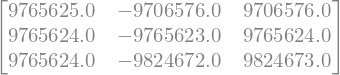

In [87]:
#Put your answer here
D_pow10 = D**10

A_pow10 = (P @ D_pow10) @ np.linalg.inv(P)

sym.Matrix(A_pow10)

&#9989; <font color=blue> **<font color=red>Do this:</font>** Now check that this answer is correct by finding $A^{10}$ by multiplying $A$ ten times.

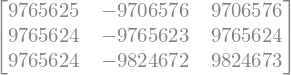

In [89]:
#Put your answer here
sym.Matrix(A**10)

&#9989; <font color=blue>**Question:</font>** What is the estimated complexity of multiplying an arbitrary $n\times n$ matrix by itself $m$ times? (Hint: both $m$ and $n$ should be included in your Big-O notation answer). 

<font size=+3>&#9998;</font> $O(m \cdot n^3)$

<font color=green>**Comment:** Diagonalization of an $n\times n$ matrix takes $O(n^3)$ operations.


---
### 1.4: Checking for diagonalizability
&#9989; <font color=blue>**<font color=red>Do this:</font>** Consider $ L = \begin{bmatrix}2&4&3\\-4&-6&-3 \\3& 3& 1\end{bmatrix}.$
Is $L$ diagonalizable? Why or why not?

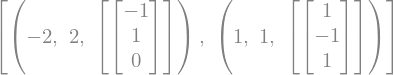

In [93]:
L=np.array([[2,4,3],[-4,-6,-3],[3,3,1]])
# Put your answer here
eigvecs = sym.Matrix(L).eigenvects()
eigvecs

No, L is not diagonalizable because it only has two linearly independent eigenvectors, which violates the rule that for an nxn size matrix there must be n linearly independent eigenvectors.

----
## 2. Introduction to Markov Models


>In probability theory, a Markov model is a stochastic model used to model randomly changing systems. 
It is assumed that future states depend only on the current state, not on the events that occurred before it.
>
> <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/2/2b/Markovkate_01.svg/1126px-Markovkate_01.svg.png" alt="State space diagram. See text for description" width=25%>
> A diagram representing a two-state Markov process, with the states labeled E and A. 
Each number represents the probability of the Markov process changing from one state to another state, with the direction indicated by the arrow. 
For example, if the Markov process is in state A, then the probability it changes to state E is 0.4, while the probability it remains in state A is 0.6.


The above state model can be represented by a transition matrix. 

At each time step ($t$) the probability to move between states depends on the previous state $t-1$:

$$A_{t} = 0.6A_{t-1}+0.7E_{t-1}$$

$$E_{t} = 0.4A_{t-1}+0.3E_{t-1}$$

The above state model ($S_t = [A_t, E_t]^T$) can be represented in the following matrix notation:


$$S_t = PS_{t-1}$$


&#9989; <font color=blue>**<font color=red>Do this:</font>** Create a $2 \times 2$ matrix $\begin{array}{cc}
P =  
\begin{bmatrix}
    p_{A\rightarrow A} & p_{E\rightarrow A}  \\
    p_{A\rightarrow E} & p_{E\rightarrow E} 
\end{bmatrix}
\end{array}
$ representing the transition matrix for the above Markov space.

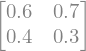

In [94]:
# Put your answer here
P = np.array([
    [0.6, 0.7],
    [0.4, 0.3]
])

sym.Matrix(P)

<font color=blue> Notice how the **columns in the matrix all add to one**. This is because all of the transition probabilities out of a matrix must add to 100 percent. 

<font color=blue> A Markov matrix $P$ always has an **eigenvalue $1$**. All other eigenvalues are in absolute value smaller or equal to $1$.

---
### 2.1: Example 1:

> Consider the following house map with cats in each room...

>At each time step, there is an equal probability of a cat staying in their current room or moving to a new room. 
If a cat chooses to leave a room, then there is an equal chance of that cat picking any of the doors in the room to leave. 

> 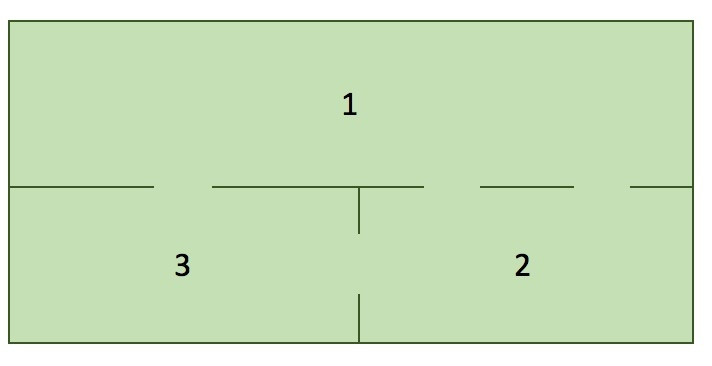

A Markov chain can be represented as a Markov transition model of the form $P\mathbf{x_1}=\mathbf{x_2}$. 
Where $P$ is your probability transition matrix, $\mathbf{x_1}$ is the state before the transition and $\mathbf{x_2}$ is the state after the transition.

**<font color=blue>Question:</font>** <font color=blue> Generate a Markov transition model represented as a matrix $P$ of the form:
<font color=blue> $$
\begin{array}{ccc}
& \text{Current Room}  \\
P =  &
\begin{bmatrix}
    p_{11} & p_{12} & p_{13} \\
    p_{21} & p_{22} & p_{23} \\
    p_{31} & p_{32} & p_{33} 
\end{bmatrix}
\end{array}
\text{Next Room},
$$

<font color=blue> where $p_{ij}$ are probability transitions of the cat moving between rooms (from room $j$ to room $i$):

In [95]:
# Put your answer here

#       1     2     3
#   1  1/2   1/3   1/4
#   2  1/3   1/2   1/4
#   3  1/6   1/6   1/2

P = np.array([
    [1/2, 1/3, 1/4],
    [1/3, 1/2, 1/4],
    [1/6, 1/6, 1/2]
])

&#9989; <font color=blue>**Do this:</font>** <font color=blue> Let's assume that the system starts with 6 cats in room 1, 15 cats in room 2, and 3 cats in room 3. On average, how many cats will be in each room after one time step? (Store the values in a vector called ```current_state```).

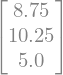

In [97]:
# Put your answer here
start_state = np.array([
    [6],
    [15],
    [3],
])

current_state = P @ start_state
sym.Matrix(current_state)

&#9989; <font color=blue>**Do this:</font>** <font color=blue> Assume that there is a total of $24$ cats in the house. Run the cell below to plot the expected number of cats as a function of time $t$.  When this system converges, what is the steady state vector?

[[9.]
 [9.]
 [6.]]


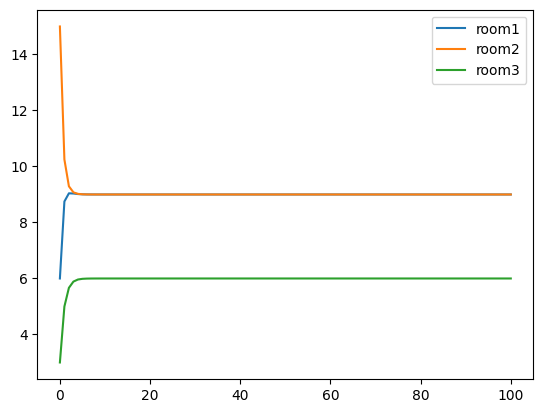

In [98]:
#Define Start State
room1 = [6]
room2 = [15]
room3 = [3]

current_state = np.matrix([room1, room2, room3])

x=np.arange(0,101)
for i in range(100):
    #update Current State
    current_state = P*current_state
    
    #Store history for each room
    room1.append(current_state[0,0])
    room2.append(current_state[1,0])
    room3.append(current_state[2,0])
    
plt.plot(x, room1, label="room1");
plt.plot(x, room2, label="room2"); 
plt.plot(x, room3, label="room3");
plt.legend();
print(current_state)

In [100]:
steady_state = np.array([
    [9],
    [9],
    [6]
])

print("Steady state vector:")
sym.Matrix(steady_state)

Steady state vector:


---
&#9989; <font color=blue>**<font color=red>Do this:</font>** Calculate the eigenvalues and eigenvectors of your transition matrix $P$.  

In [106]:
# Put your answer here
eigvecs = sym.Matrix(P).eigenvects()
eigvec1 = eigvecs[0][2][0]
eigvec2 = eigvecs[1][2][0]
eigvec3 = eigvecs[2][2][0]

eigval1 = eigvecs[0][0]
eigval2 = eigvecs[1][0]
eigval3 = eigvecs[2][0]

The eigenvector associated with the eigenvalue of $1$ represents the **steady state** probability for our original transition matrix $P$.  

&#9989; <font color=blue>**<font color=red>Do this:</font>** make a new vector called ```steadystate``` from the eigenvector of your $P$ matrix with a eigenvalue of 1.

In [108]:
eigval2

In [110]:
steady_state = eigvec2

Since the ```steadystate``` vectors represent long term probabilities, they should sum to one (1).  However, many programming libraries (including `numpy`) return "normalized" eigenvectors to length of 1 (i.e. norm(e)==1). 

&#9989; <font color=blue>**<font color=red>Do this:</font>**  Multiply the ```steadystate``` eigenvector by a constant such that the sum of the vector elements add to 1 to correct for the normalization of `numpy`.

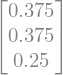

In [115]:
# Put your answer here
ss_len = sum(steady_state)

steady_state /= ss_len
steady_state

The steady state represents the proportion of cats that will be in each room. But since we know the initial number of cats, we can find how these cats arrange themselves in the steady state

&#9989; <font color=blue>**<font color=red>Do this:</font>** Multiply the vector `steadystate` by the total number of cats. Confirm that the resulting vector is identical to the steady state vector you obtained in the above chart.

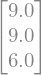

In [116]:
# Put your answer here
num_cats = 24

num_cats * steady_state

&#9989; <font color=blue>**<font color=red>Do this:</font>** Why does the sum of the numbers at every stage remain the same? 


<font size=+3>&#9998;</font> The sum of the numbers at every stage remains the same because it is always representing the current state, which is the total number of cats in this scenario. The Markov model in this situation is a closed process, so the cats can neither enter/birth or leave/die, meaning that the population will be fixed at 24.

---
### 2.2 (_Time permitting_) Example 2

> A sports broadcaster wishes to predict how many Michigan residents prefer University of Michigan teams and how many prefer Michigan State teams. 
She noticed that, year after year, most people stick with their preferred team; however, about 5% of Michigan fans switch to Michigan State, and about 3% of Michigan State fans switch to Michigan each year. 
However, there is no noticeable difference in the state's population of 10 million's preference at large; in other words, it seems Michigan sports fans have reached a stationary distribution. What might that be?


&#9989; <font color=blue>**<font color=red>Do this:</font>** Try to draw a Markov chain for the above system of equations. Discuss your diagram with your classmates.

`` Import a photo of your diagram here``

&#9989; <font color=blue>**<font color=red>Do this:</font>**  Write a system of linear equations that represents how the populations change each year. Check your equations by writing the matrix ```P``` for the probability transitions matrix in your equations. Make sure your first row/column represents MSU and the second row/column represents UofM. 

In [6]:
# Put your answer here

&#9989; <font color=blue>**<font color=red>Do this:</font>**  Use Numpy to calculate the eigenvalues and eigenvectors of your transition matrix $P$.  

In [5]:
# Put your answer here

**<font color=blue>Question:</font>**   <font color=blue> Assuming both teams start with 500,000 fans each (so 1,000,000 fans total), what is the steady state of this model? (I.e. in the long term how many Spartan and Wolverine fans will there be?).

In [4]:
# Put your answer here

---
## Congratulations, you're done!
## Before you close or submit this In-Class Assignment, please make sure of a few things:
- Save your work (Ctrl + S) and export the notebook as a .pdf (Ctrl/Command + P → Save as PDF), or use an online ipynb to pdf converter if that fails.
- Ensure images render correctly in the PDF; if not, use
  ``` 
  from IPython.display import display, Image
  display(Image(filename="a.jpg", height=400, width=400))
  ``` 
  This works for JPGs only.
- Verify the PDF contents before submitting — make sure it is not empty and includes all material.

